In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('/Users/sreenidhi/Documents/GitHub/data-viz-class-material/data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))

Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


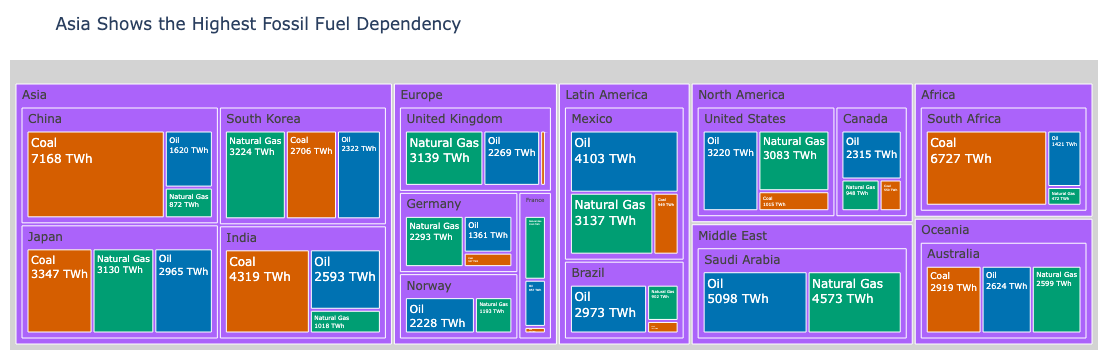

In [30]:
# Filter only fossil fuel sources
fossil_df = df.loc[df['Source_Type'] == 'Fossil']

# Find the most fossil-dependent region
top_region = (
    fossil_df.groupby('Region')['TWh']
    .sum()
    .sort_values(ascending=False)
    .idxmax()
)

# Treemap
fig = px.treemap(
    fossil_df,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#D55E00',         # CVD-safe orange
        'Oil': '#0072B2',          # CVD-safe blue
        'Natural Gas': '#009E73'   # CVD-safe green
    },
    title=f'{top_region} Shows the Highest Fossil Fuel Dependency'
)

# Show TWh values instead of percentages
fig.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value} TWh',
    
    # Grey parent nodes
    root_color='lightgrey'
)

# Layout cleanup
fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

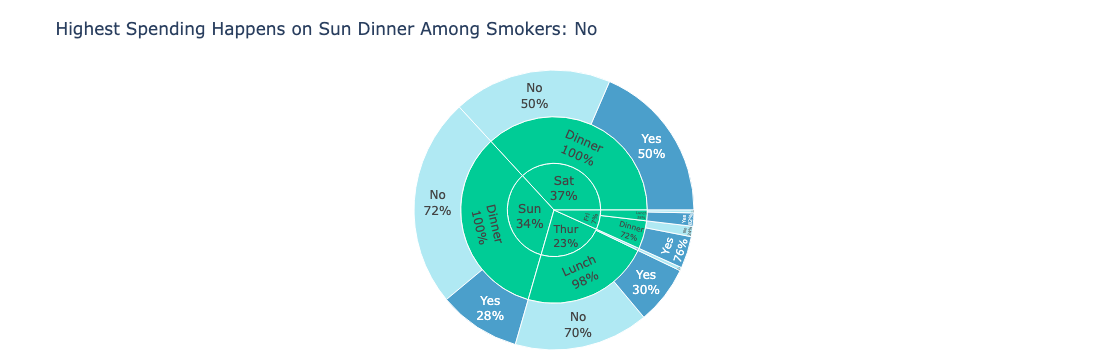

In [15]:
# Load built-in tips dataset
tips = px.data.tips()

# Aggregate total bill amount
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# Find where the highest spending happens
top_spending = (
    tips_grouped.sort_values(by='total_bill', ascending=False)
    .iloc[0]
)

# Sunburst chart
fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#0077B6',  
        'No': '#DDB892'     
    },
    title=f'Highest Spending Happens on {top_spending["day"]} {top_spending["time"]} Among Smokers: {top_spending["smoker"]}'
)

# Grey out parent nodes + show percent of parent
fig.update_traces(
    textinfo='label+percent parent',
    root_color='lightgrey'
)

# Layout cleanup
fig.update_layout(
    margin=dict(t=70, l=10, r=10, b=10)
)

fig.show()

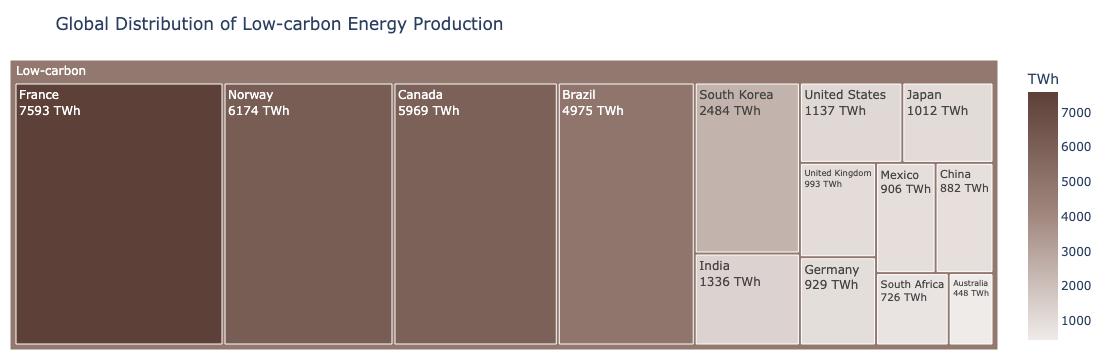

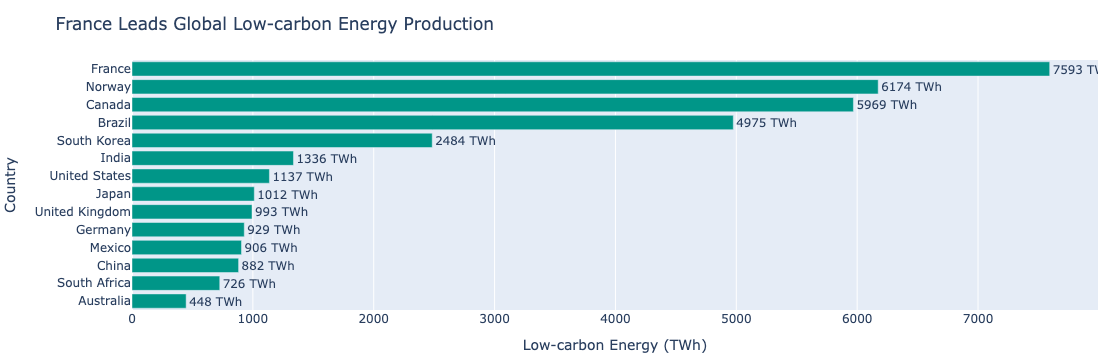

In [9]:
# Filter only low-carbon sources
low_carbon_df = df.loc[df['Source_Type'] == 'Low-carbon']

# Aggregate total TWh by country
country_lowcarbon = (
    low_carbon_df.groupby('Country')['TWh']
    .sum()
    .reset_index()
)

# Add dummy root node for treemap
country_lowcarbon['All'] = 'Low-carbon'

# Find leading country
top_country = (
    country_lowcarbon.sort_values(by='TWh', ascending=False)
    .iloc[0]['Country']
)

# -----------------------------------
# TREEMAP
# -----------------------------------
fig_tree = px.treemap(
    country_lowcarbon,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',

    # Brown / earthy gradient
    color_continuous_scale=[
        '#EFEBE9',   # light beige
        '#A1887F',   # medium brown
        '#5D4037'    # dark brown
    ],

    title='Global Distribution of Low-carbon Energy Production'
)

# Show labels with TWh values
fig_tree.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value} TWh',
    root_color='lightgrey'
)

fig_tree.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig_tree.show()

# -----------------------------------
# HORIZONTAL BAR CHART
# -----------------------------------

# Sort values for better readability
country_lowcarbon_sorted = country_lowcarbon.sort_values(
    by='TWh',
    ascending=True
)

fig_bar = px.bar(
    country_lowcarbon_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    title=f'{top_country} Leads Global Low-carbon Energy Production'
)

# Apply CVD-safe colour and labels
fig_bar.update_traces(
    marker_color='#009688',   # teal colour
    texttemplate='%{x} TWh',
    textposition='outside'
)

# Layout cleanup
fig_bar.update_layout(
    xaxis_title='Low-carbon Energy (TWh)',
    yaxis_title='Country',
    showlegend=False,
    margin=dict(t=60, l=10, r=10, b=10)
)

fig_bar.show()